# Monte Carlo Simulation of a Term Life Insurance Portfolio

### Objective

This project estimates the annual profitability of a portfolio of term life insurance policies using Monte Carlo simulation.

Rather than assuming a fixed number of claims each year, thousands of possible outcomes are simulated to understand:

- Expected annual profit
- Profit variability
- Downside risk
- Impact of changing assumptions

This approach demonstrates how uncertainty can be incorporated into financial decision making.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline
np.random.seed(42)

## Baseline Monte Carlo Model

The initial model assumes that every policyholder has the same annual mortality probability.

Although simplified, this provides a useful baseline for understanding the relationship between mortality risk and portfolio profitability before introducing more realistic assumptions.

In [3]:
number_of_policies = 10000
annual_premium = 500
death_benefit = 100000
annual_mortality_probability = 0.0015
number_of_simulations = 10000

### Assumptions

Each policyholder:

- Pays an annual premium of **$500**

- Receives a **$100,000** death benefit if they die during the year
- Has a **0.15%** annual probability of death

The portfolio contains **10,000** independent policyholders.

In [4]:
deaths = np.random.binomial(n=1, p=annual_mortality_probability, size=number_of_policies)

In [5]:
premium_income = number_of_policies * annual_premium
claims_paid = deaths.sum() * death_benefit
profit = premium_income - claims_paid

print(f"Deaths: {deaths.sum()}")
print(f"Profit: ${profit:,.0f}")

Deaths: 12
Profit: $3,800,000


### Why a Binomial Distribution?

Each policyholder experiences one of two possible outcomes during the year:

- Survives (no claim)
- Dies (insurance claim)

Because these are binary outcomes, each policyholder can be modeled as a Bernoulli trial with a fixed probability of death.

Assuming policyholders are independent and share the same annual mortality probability, the total number of claims across the portfolio follows a binomial distribution.

Monte Carlo simulation repeatedly samples from this distribution to estimate the range of possible annual profits, rather than relying on a single expected value. This provides insight into both expected performance and the variability of financial outcomes.

In [6]:
def simulate_year():

    deaths = np.random.binomial(n=1, p=annual_mortality_probability, size=number_of_policies)

    premium_income = number_of_policies * annual_premium
    claims_paid = deaths.sum() * death_benefit
    profit = premium_income - claims_paid

    return profit

In [7]:
profits = []

for _ in range(number_of_simulations):
    profits.append(simulate_year())

profits = np.array(profits)

### Baseline Results

After running 10,000 simulations, the following statistics summarize the expected financial performance of the insurance portfolio.

In [8]:
print(f"Average Profit: ${profits.mean():,.0f}")
print(f"Median Profit: ${np.median(profits):,.0f}")
print(f"Standard Deviation: ${profits.std():,.0f}")
print(f"Minimum Profit: ${profits.min():,.0f}")
print(f"Maximum Profit: ${profits.max():,.0f}")

Average Profit: $3,499,770
Median Profit: $3,500,000
Standard Deviation: $387,023
Minimum Profit: $1,600,000
Maximum Profit: $4,800,000


In [9]:
lower = np.percentile(profits, 2.5)
upper = np.percentile(profits, 97.5)

print(f"95% Confidence Interval:")
print(f"${lower:,.0f} to ${upper:,.0f}")

95% Confidence Interval:
$2,700,000 to $4,200,000


### Distribution of Annual Profit

The histogram below illustrates the distribution of annual profit across all simulated years.

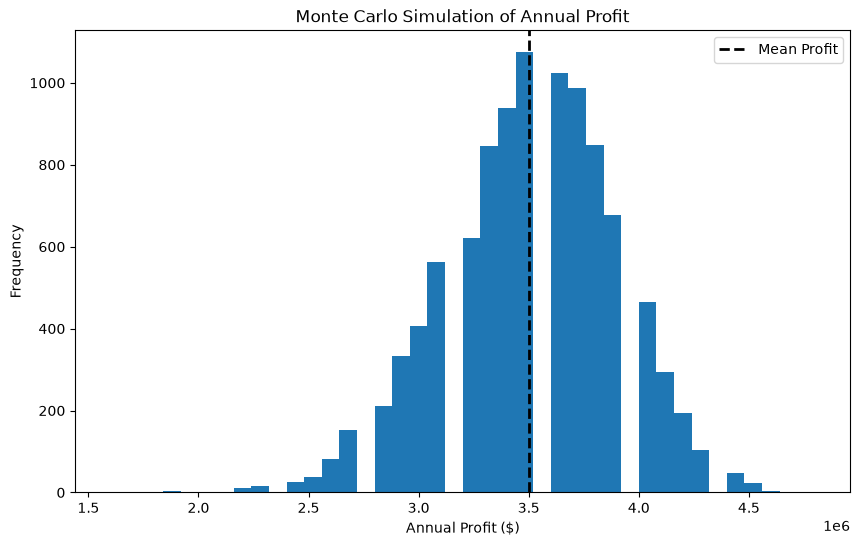

In [10]:
plt.figure(figsize=(10,6))
plt.hist(profits, bins=40)

plt.axvline(profits.mean(), linestyle="--", linewidth=2, label="Mean Profit", color="Black")

plt.legend()
plt.xlabel("Annual Profit ($)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Simulation of Annual Profit")

plt.show()

### Baseline Model Interpretation

The baseline model estimates the expected annual profit and the variability of outcomes using a single mortality assumption for all policyholders.

While useful as a starting point, this approach does not reflect differences in risk across individuals.

In [11]:
probability_of_loss = np.mean(profits < 0)

print(f"Probability of Loss: {probability_of_loss:.4%}")

Probability of Loss: 0.0000%


In [12]:
worst_5 = np.percentile(profits, 5)

print(f"5th Percentile Profit: ${worst_5:,.0f}")

5th Percentile Profit: $2,800,000


In [13]:
def simulate_portfolio(mortality_rate):

    profits = []

    for _ in range(number_of_simulations):

        deaths = np.random.binomial(n=1, p=mortality_rate, size=number_of_policies)

        premium_income = number_of_policies * annual_premium
        claims_paid = deaths.sum() * death_benefit
        profits.append(premium_income - claims_paid)

    return np.mean(profits)

In [14]:
mortality_rates = [0.001, 0.0015, 0.002, 0.0025, 0.003, 0.004]

average_profits = []

for rate in mortality_rates:
    average_profits.append(simulate_portfolio(rate))

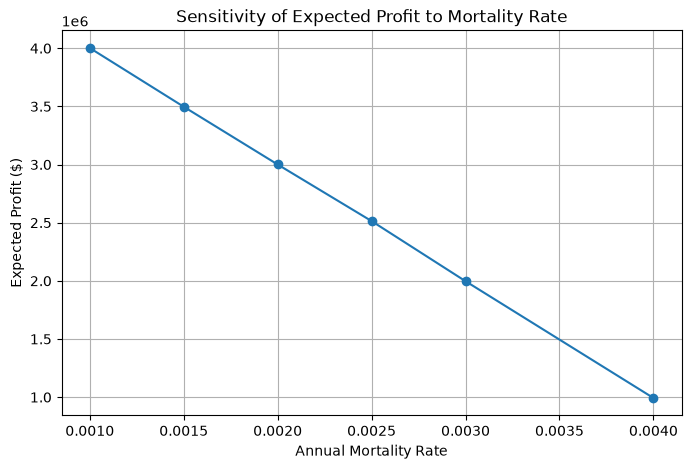

In [15]:
plt.figure(figsize=(8,5))

plt.plot(mortality_rates, average_profits, marker='o')

plt.xlabel("Annual Mortality Rate")
plt.ylabel("Expected Profit ($)")
plt.title("Sensitivity of Expected Profit to Mortality Rate")
plt.grid(True)

plt.show()

# Model Enhancement

The initial model assumed every policyholder shared the same mortality probability.

To make the simulation more realistic, the portfolio is extended to include multiple age groups, each with its own mortality rate.

In [16]:
portfolio = pd.DataFrame({"Age Group": np.random.choice([30,45,60], size=number_of_policies, p=[0.40,0.35,0.25])})

In [17]:
mortality_lookup = {30:0.0008, 45:0.0018, 60:0.0065}

portfolio["Mortality Rate"] = portfolio["Age Group"].map(mortality_lookup)

In [18]:
def simulate_year_age_based():

    deaths = np.random.binomial(n=1, p=portfolio["Mortality Rate"])

    premium_income = number_of_policies * annual_premium
    claims_paid = deaths.sum() * death_benefit

    return premium_income - claims_paid

In [19]:
age_based_profits = []

for _ in range(number_of_simulations):
    age_based_profits.append(simulate_year_age_based())

age_based_profits = np.array(age_based_profits)

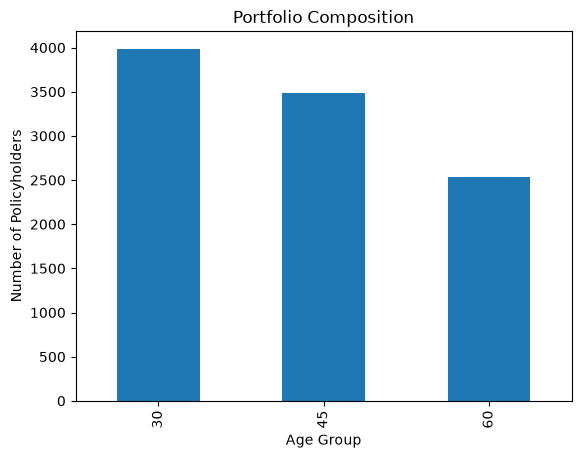

In [20]:
portfolio["Age Group"].value_counts().sort_index().plot(kind="bar")

plt.title("Portfolio Composition")
plt.xlabel("Age Group")
plt.ylabel("Number of Policyholders")

plt.show()

In [21]:
comparison = pd.DataFrame({"Basic Model": [profits.mean(), profits.std(), np.percentile(profits, 5)],
                           "Age-Based Model": [age_based_profits.mean(), age_based_profits.std(), 
                                               np.percentile(age_based_profits, 5)]}, 
                          index=["Mean Profit", "Standard Deviation","5th Percentile"])

comparison.round(0)

,Basic Model,Age-Based Model
Mean Profit,3499770.0,2408970.0
Standard Deviation,387023.0,510328.0
5th Percentile,2800000.0,1600000.0


### Comparing the Two Models

Comparing the baseline and enhanced models illustrates the impact of improving model assumptions.

Although both models estimate profitability, incorporating heterogeneous risk better reflects how insurers evaluate real-world portfolios.

The enhanced model provides a more realistic representation of portfolio risk by accounting for differing mortality rates across policyholders. This richer model forms the basis for the pricing analysis presented in the next section.

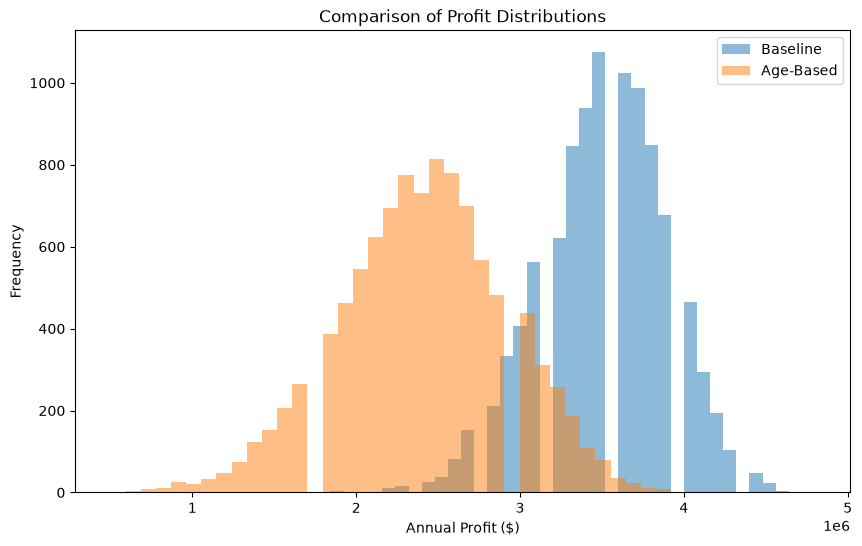

In [22]:
plt.figure(figsize=(10,6))

plt.hist(profits, bins=40, alpha=0.5, label="Baseline")
plt.hist(age_based_profits, bins=40, alpha=0.5, label="Age-Based")

plt.legend()
plt.xlabel("Annual Profit ($)")
plt.ylabel("Frequency")
plt.title("Comparison of Profit Distributions")

plt.show()

In [23]:
def simulate_portfolio(premium):

    profits = []

    for _ in range(number_of_simulations):

        deaths = np.random.binomial(n=1, p=portfolio["Mortality Rate"])

        premium_income = number_of_policies * premium
        claims_paid = deaths.sum() * death_benefit

        profits.append(premium_income - claims_paid)

    return np.mean(profits)

In [24]:
premiums = np.arange(300,701,25)

expected_profit = []

for premium in premiums:
    expected_profit.append(simulate_portfolio(premium))

### Premium Optimization

The enhanced model can also be used as a pricing decision-support tool.

Rather than simply estimating profitability, the simulation evaluates how different premium levels influence expected financial performance.

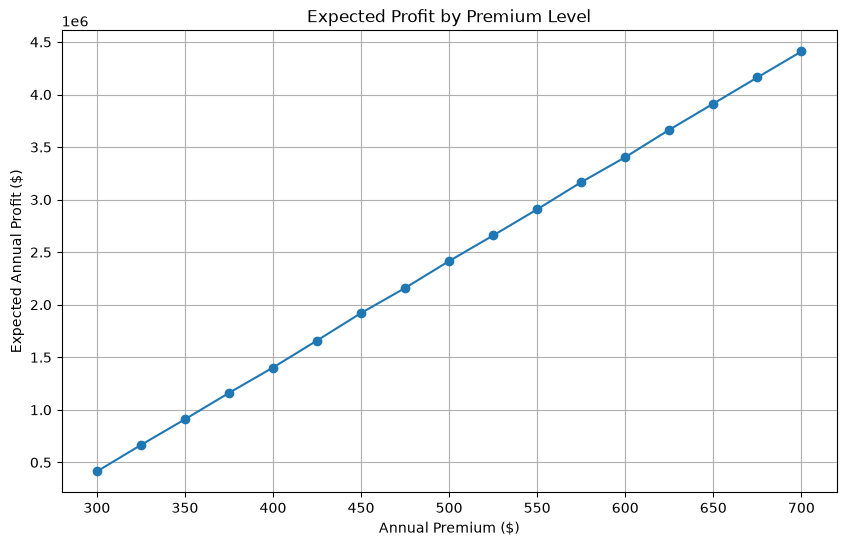

In [25]:
plt.figure(figsize=(10,6))

plt.plot(premiums, expected_profit, marker="o")

plt.xlabel("Annual Premium ($)")
plt.ylabel("Expected Annual Profit ($)")
plt.title("Expected Profit by Premium Level")
plt.grid(True)

plt.show()

In [26]:
target_profit = 2_000_000

closest = np.argmin(np.abs(np.array(expected_profit)-target_profit))

print("Recommended Premium")
print(f"${premiums[closest]}")

Recommended Premium
$450


# Business Conclusions

This project demonstrates how Monte Carlo simulation can support insurance pricing and risk assessment.

Key findings include:

- Expected profitability can be estimated while accounting for uncertainty.
- Portfolio outcomes are sensitive to mortality assumptions.
- Incorporating age-specific mortality creates a more realistic representation of insurance risk.
- The simulation can be adapted to evaluate pricing strategies and support business decision-making.

Monte Carlo simulation provides decision-makers with a probabilistic view of financial outcomes rather than relying solely on deterministic estimates.

# Future Enhancements

Potential improvements include:

- Using published actuarial mortality tables
- Modeling multiple policy types
- Including policy lapses and cancellations
- Incorporating investment income
- Modeling inflation and discount rates
- Simulating multi-year policy lifecycles
- Introducing stochastic interest rates
- Comparing pricing strategies using optimization techniques

# Project Summary

This project demonstrates how Monte Carlo simulation can be applied to estimate uncertainty in insurance portfolio profitability.

Starting from a simplified model, the analysis was progressively enhanced by introducing age-based mortality assumptions and using the resulting model to evaluate premium pricing decisions.

The project illustrates several concepts commonly used in actuarial science and quantitative finance, including probability distributions, simulation, sensitivity analysis, risk assessment, and decision support.

### Skills Demonstrated

This project demonstrates:

- Monte Carlo Simulation
- Probability and Statistics
- Financial Modeling
- Risk Analysis
- Sensitivity Analysis
- Data Visualization
- Python Programming
- Decision Support Modeling